# Practical 7: Random Forests, OOB Error, Bagging and Feature Subsampling

## Student Placement Prediction

### Aim
Implement and analyse Random Forests using training and validation data, study OOB error convergence, compare `max_features`, demonstrate manual bootstrap bagging, calculate permutation importance, and compare a Random Forest with a single Decision Tree.

### Dataset
This notebook is adapted to the project's **50,000-row placement dataset**:

`../data/placement_predict_50k Dataset_final.csv`

The target is `PlacementStatus` (`0 = Not Placed`, `1 = Placed`).

> The original template mentioned a 14-row teaching dataset. That text has been updated because this project uses the 50,000-row placement dataset.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)


## 2. Load the Dataset

In [2]:
# ============================================================
# 2. LOAD CSV DATASET
# ============================================================

CSV_PATH = "../data/placement_predict_50k Dataset_final.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nPlacementStatus distribution:")
print(df["PlacementStatus"].value_counts(dropna=False))


Dataset loaded successfully.
Shape: (50000, 32)

Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

PlacementStatus distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. BASIC DATA CHECK
# ============================================================

print("Missing values in each column:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)


Missing values in each column:
StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA                     0
AttendancePercent        0
Internships              0
Projects                 0
Workshops             4488
Certifications           0
Publications             0
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
MockInterviewScore    4957
ExtraCurricular          0
CGPA_Tier                0
PlacementStatus          0
IsAnomaly                0
Salary Package           0
dtype: int64

Data types:
StudentID               int64
Gender                    str
City               

## 3. Prepare the Target and Features

We will:
- use `PlacementStatus` as the target;
- remove `StudentID` because it is only an identifier;
- remove `Salary Package` because it is an outcome/value associated with placement and should not be used to predict placement status;
- keep the remaining columns as candidate features.

`PlacementStatus` is already numeric in this dataset, so we **do not** apply the old Yes/No mapping to it.


In [4]:
# ============================================================
# 4. DEFINE X AND y
# ============================================================

DROP_COLUMNS = [
    "StudentID",
    "PlacementStatus",
    "Salary Package"
]

X = df.drop(columns=DROP_COLUMNS, errors="ignore").copy()
y = df["PlacementStatus"].copy()

# Make sure the target is numeric and contains no missing values.
y = pd.to_numeric(y, errors="coerce")

if y.isna().any():
    raise ValueError(
        f"PlacementStatus contains {y.isna().sum()} missing/non-numeric values. "
        "Fix the target before training."
    )

y = y.astype(int)

print("Features:")
print(X.columns.tolist())

print("\nTarget: PlacementStatus")
print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget data type:", y.dtype)


Features:
['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'IsAnomaly']

Target: PlacementStatus

Target distribution:
PlacementStatus
0    17144
1    32856
Name: count, dtype: int64

Target data type: int64


In [5]:
# ============================================================
# 5. IDENTIFY FEATURE TYPES
# ============================================================

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

print("\nNumber of numeric features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))


Numeric columns: ['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly']

Categorical columns: ['Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'CGPA_Tier']

Number of numeric features: 21
Number of categorical features: 8


## Step 4 — Training and Validation Data

The same 70/30 split is used throughout the practical so the models are compared on the same validation data.


In [6]:
# ============================================================
# 6. TRAIN / VALIDATION SPLIT
# ============================================================

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_raw))
print("Validation samples:", len(X_val_raw))

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts().sort_index())


Training samples: 35000
Validation samples: 15000

Training class distribution:
PlacementStatus
0    12001
1    22999
Name: count, dtype: int64

Validation class distribution:
PlacementStatus
0    5143
1    9857
Name: count, dtype: int64


## 5. Preprocess Features

The Decision Tree and Random Forest require numerical input.

The raw dataset contains categorical values such as `Male`, `Female`, `Tier1`, etc. We therefore:
- fill missing numeric values with the training median;
- fill missing categorical values with the most frequent category;
- one-hot encode categorical features.

The preprocessing is fitted **only on the training data** and then applied to validation data.


In [7]:
# ============================================================
# 7. PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train_raw)
X_val_processed = preprocessor.transform(X_val_raw)

feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_raw.index
)

X_val = pd.DataFrame(
    X_val_processed,
    columns=feature_names,
    index=X_val_raw.index
)

print("Processed X_train shape:", X_train.shape)
print("Processed X_val shape:", X_val.shape)

print("\nAll processed features are numeric:")
print(X_train.dtypes.value_counts())


Processed X_train shape: (35000, 53)
Processed X_val shape: (15000, 53)

All processed features are numeric:
float64    53
Name: count, dtype: int64


In [8]:
# ============================================================
# 8. VERIFY PROCESSED DATA
# ============================================================

print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_val:", X_val.isna().sum().sum())

print("Non-numeric columns in X_train:",
      X_train.select_dtypes(exclude="number").columns.tolist())

print("\nFirst 5 processed rows:")
display(X_train.head())


Missing values in X_train: 0
Missing values in X_val: 0
Non-numeric columns in X_train: []

First 5 processed rows:


,num__SGPA_Sem1,num__SGPA_Sem2,num__SGPA_Sem3,num__SGPA_Sem4,num__SGPA_Sem5,num__SGPA_Sem6,num__SGPA_Sem7,num__SGPA_Sem8,num__CGPA,num__AttendancePercent,num__Internships,num__Projects,num__Workshops,num__Certifications,num__Publications,num__AptitudeTestScore,num__SoftSkillsRating,num__CodingTestScore,num__MockInterviewScore,num__ExtraCurricular,num__IsAnomaly,cat__Gender_Female,cat__Gender_Male,cat__City_Ahmedabad,cat__City_Bangalore,cat__City_Chennai,cat__City_Delhi,cat__City_Hyderabad,cat__City_Jaipur,cat__City_Kochi,cat__City_Kolkata,cat__City_Mumbai,cat__City_Pune,cat__CollegeTier_Tier1,cat__CollegeTier_Tier2,cat__CollegeTier_Tier3,cat__Stream_CS,cat__Stream_Civil,cat__Stream_ECE,cat__Stream_EE,cat__Stream_IT,cat__Stream_Mechanical,cat__Specialisation_AI,cat__Specialisation_DataScience,cat__Specialisation_Embedded,cat__Specialisation_Networking,cat__Hostel_No,cat__Hostel_Yes,cat__HistoryOfBacklogs_No,cat__HistoryOfBacklogs_Yes,cat__CGPA_Tier_High,cat__CGPA_Tier_Low,cat__CGPA_Tier_Mid
15225,7.42,7.25,7.14,7.58,7.95,7.84,7.67,7.32,4.00,51.343357,2.0,3.0,2.0,4.0,1.0,32.7,3.7,9.0,80.1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
25552,4.13,4.69,4.65,4.78,4.30,4.00,4.26,4.77,4.26,64.900000,0.0,0.0,1.0,0.0,0.0,43.2,2.1,26.3,29.2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
21568,8.21,7.34,8.29,7.48,7.73,8.28,8.30,8.01,8.01,73.400000,1.0,1.0,1.0,1.0,1.0,67.4,2.4,57.7,54.8,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
37916,6.67,6.37,6.10,6.25,6.37,6.41,6.35,6.37,6.23,66.200000,1.0,2.0,1.0,1.0,1.0,60.9,3.2,66.6,48.4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
12999,7.41,7.63,8.43,7.71,7.62,7.22,7.81,7.12,7.69,86.700000,2.0,3.0,4.0,2.0,2.0,73.7,4.6,80.2,80.7,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


# Part A — Single Decision Tree Baseline

First build one Decision Tree. This is the baseline against which the Random Forest will be compared.


In [9]:
# ============================================================
# 9. SINGLE DECISION TREE BASELINE
# ============================================================

dt_baseline = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_val_acc = accuracy_score(y_val, dt_val_pred)

print("SINGLE DECISION TREE")
print("=" * 50)
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")


SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.8891
Tree Depth          : 36
Number of Leaves    : 1723


# Part B — Random Forest

A Random Forest combines many Decision Trees.

Important parameters:
- `n_estimators` → number of trees;
- `bootstrap=True` → bootstrap samples are used;
- `oob_score=True` → calculate Out-of-Bag accuracy;
- `max_features` → number of features considered at each split.


In [10]:
# ============================================================
# 10. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)

print("RANDOM FOREST")
print("=" * 50)
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")


RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.9199
OOB Accuracy        : 0.9206
OOB Error           : 0.0794


In [11]:
# ============================================================
# 11. INSPECT RANDOM FOREST
# ============================================================

print("Number of trees:", len(rf.estimators_))
print("First tree:", rf.estimators_[0])


Number of trees: 100
First tree: DecisionTreeClassifier(criterion='entropy', max_features='sqrt',
                       random_state=1608637542)


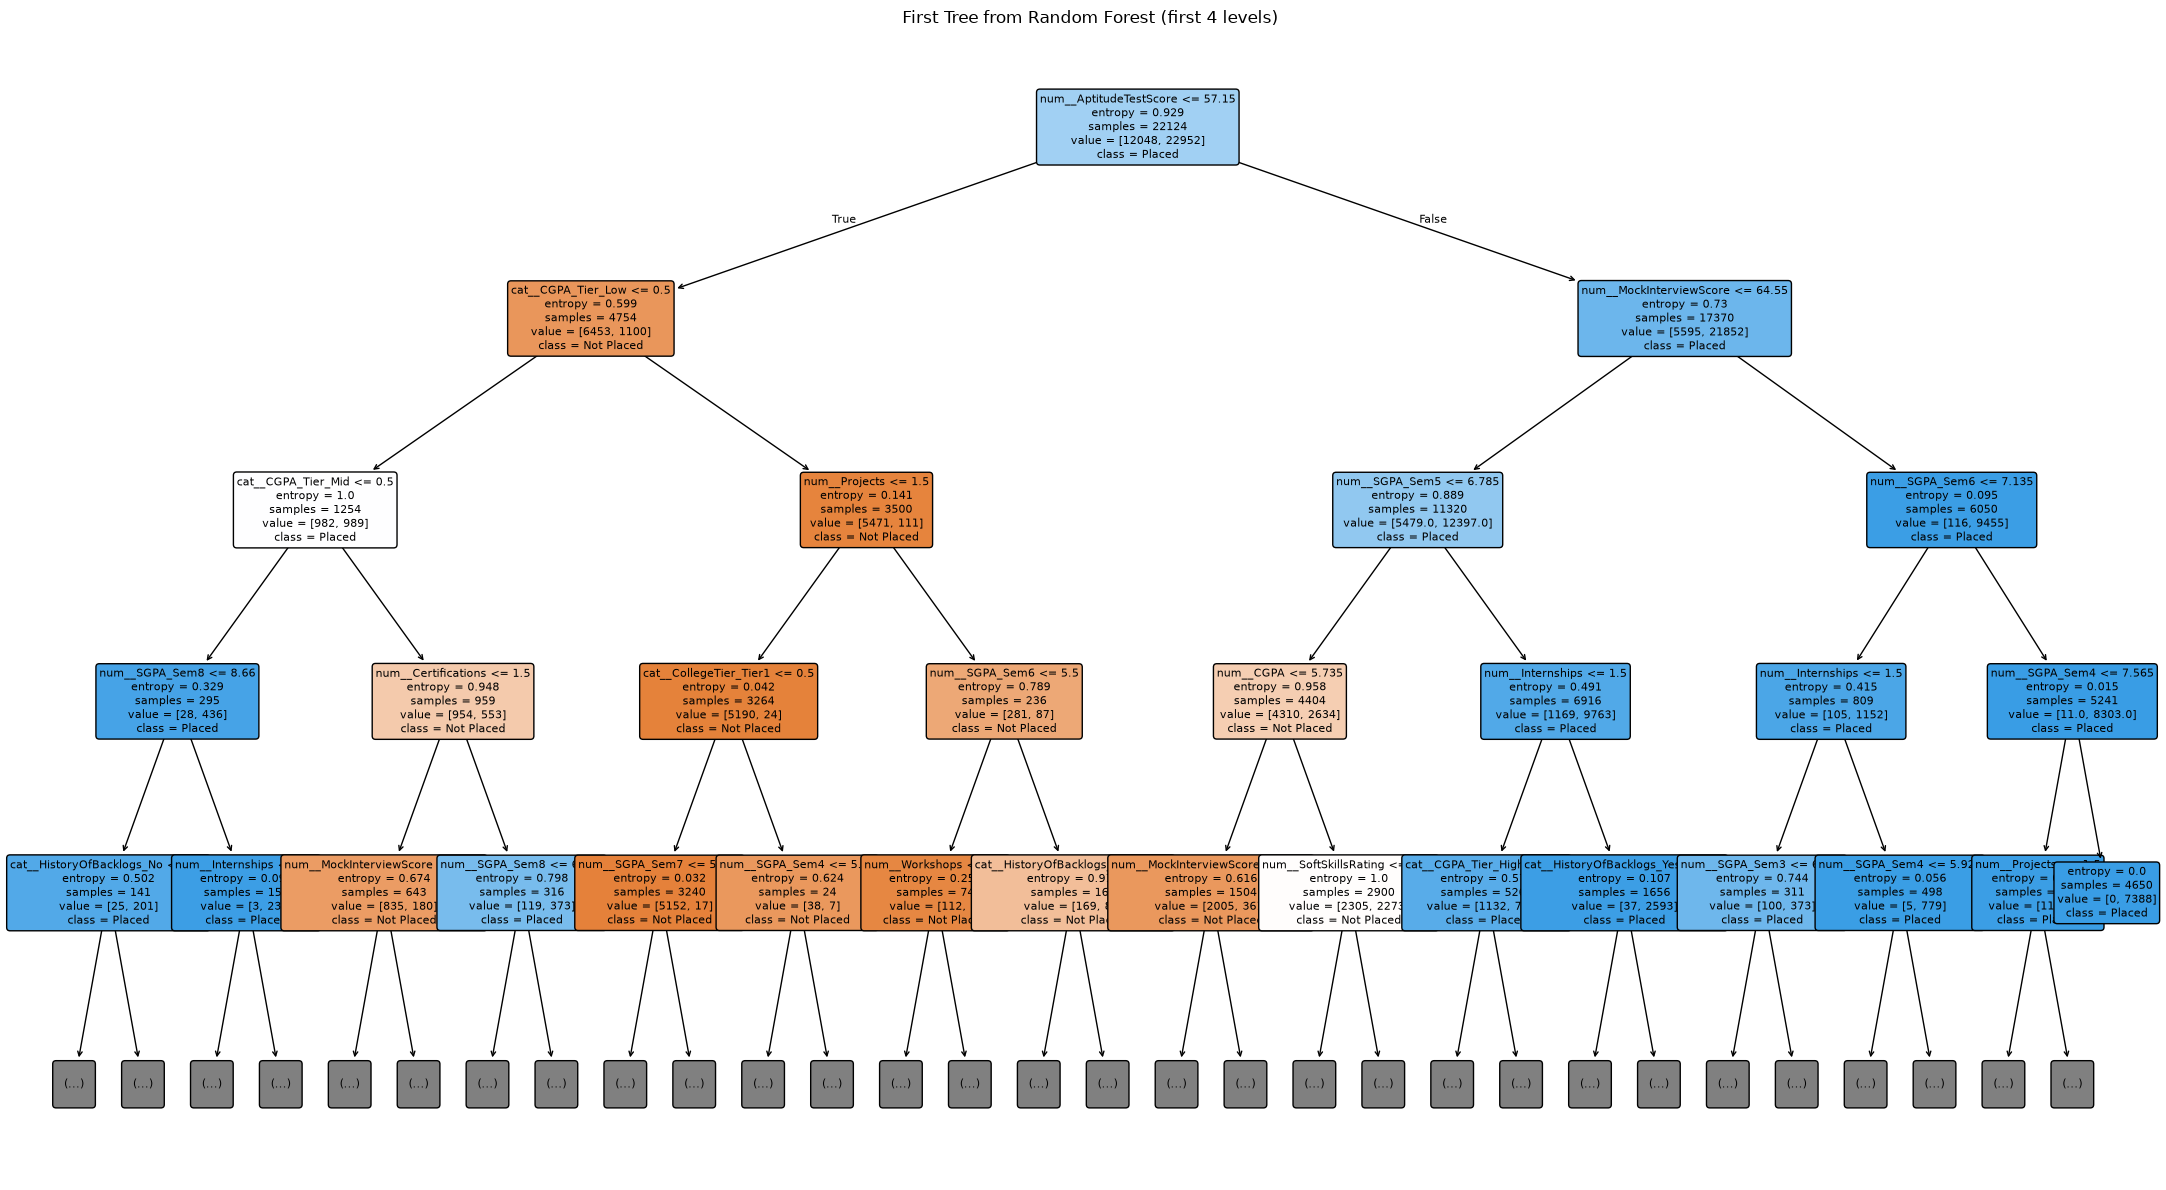

In [12]:
# ============================================================
# 12. PLOT ONE TREE FROM THE RANDOM FOREST
# ============================================================

plt.figure(figsize=(22, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=feature_names,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=8
)

plt.title("First Tree from Random Forest (first 4 levels)")
plt.tight_layout()
plt.show()


In [13]:
# ============================================================
# 13. RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_val,
    rf_val_pred,
    target_names=["Not Placed", "Placed"],
    zero_division=0
))


              precision    recall  f1-score   support

  Not Placed       0.91      0.85      0.88      5143
      Placed       0.93      0.95      0.94      9857

    accuracy                           0.92     15000
   macro avg       0.92      0.90      0.91     15000
weighted avg       0.92      0.92      0.92     15000



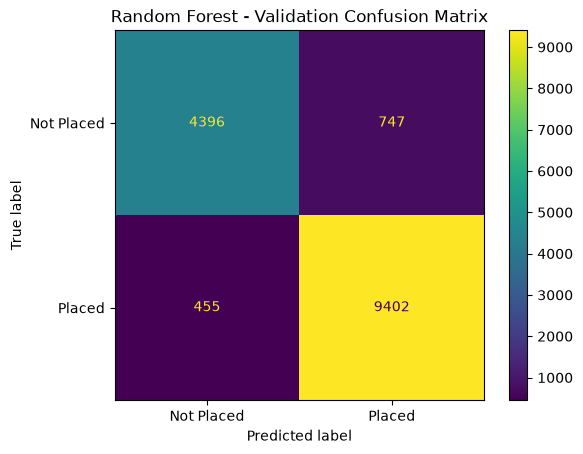

In [14]:
# ============================================================
# 14. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, rf_val_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
).plot()

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()


# Part C — OOB Error Convergence

For each tree, some training observations are left out of its bootstrap sample. These are Out-of-Bag observations.

We measure OOB accuracy/error for increasing numbers of trees.


In [15]:
# ============================================================
# 15. OOB ERROR CONVERGENCE
# ============================================================

# Start at 5 trees so the OOB estimate is meaningful enough
# for this experiment; very small forests produce unstable OOB estimates.
n_estimators_values = [5, 10, 20, 30, 50, 75, 100, 150, 200]

oob_results = []

for n in n_estimators_values:
    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_Accuracy": oob_acc,
        "OOB_Error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))


/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_Accuracy,OOB_Error
0,5,0.8284,0.1716
1,10,0.8912,0.1088
2,20,0.9101,0.0899
3,30,0.9139,0.0861
4,50,0.9193,0.0807
5,75,0.9200,0.0800
6,100,0.9206,0.0794
7,150,0.9216,0.0784
8,200,0.9229,0.0771


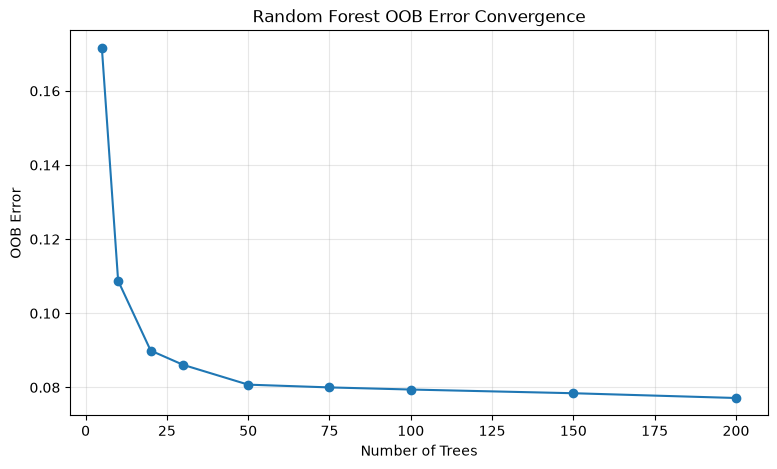

In [16]:
# ============================================================
# 16. PLOT OOB ERROR CONVERGENCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_Error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")
plt.grid(True, alpha=0.3)
plt.show()


### Student observation

Look for the region where OOB error becomes relatively stable. Increasing the number of trees generally makes the OOB estimate more stable, although the exact values depend on the dataset.


# Part D — `max_features` Comparison

`max_features` controls how many features are considered when a tree searches for a split.

We compare:
- `sqrt`
- `log2`
- `None` → all features

This demonstrates **feature subsampling**.


In [17]:
# ============================================================
# 17. COMPARE max_features
# ============================================================

max_features_values = ["sqrt", "log2", None]
max_features_results = []

for mf in max_features_values:
    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Train_Accuracy": accuracy_score(y_train, train_pred),
        "Validation_Accuracy": accuracy_score(y_val, val_pred),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(max_features_results)

display(max_features_df.round(4))


,max_features,Train_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.9199,0.9206,0.0794
1,log2,1.0,0.9176,0.9206,0.0794
2,None,1.0,0.9212,0.9208,0.0792


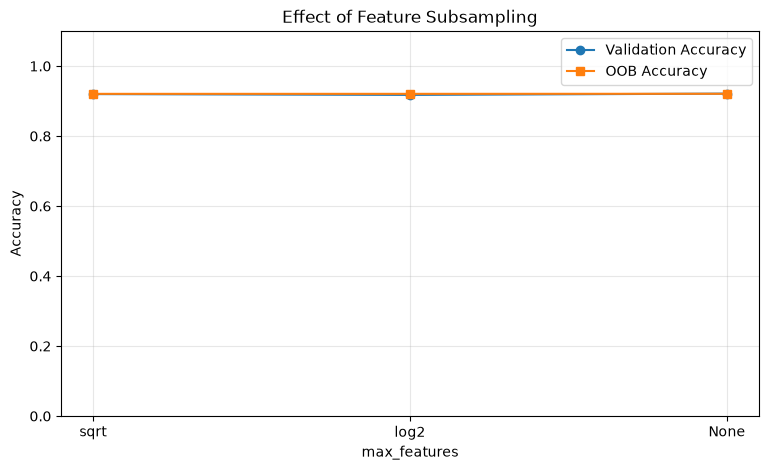

In [18]:
# ============================================================
# 18. PLOT max_features COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")
plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()


# Part E — Manual Bootstrap Bagging

A bootstrap sample is created by sampling training rows **with replacement**. Different trees receive different bootstrap samples.


In [19]:
# ============================================================
# 19. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    np.unique(indices)
)

print("Total bootstrap observations:", len(indices))
print("Unique observations selected:", len(np.unique(indices)))
print("OOB observations:", len(oob_indices))

print("\nFirst 30 bootstrap indices:")
print(indices[:30])

print("\nFirst 30 OOB indices:")
print(oob_indices[:30])


Total bootstrap observations: 35000
Unique observations selected: 22110
OOB observations: 12890

First 30 bootstrap indices:
[ 3123 27088 22910 15360 15155 30050  3008 24407  7051  3296 18426 34146
 25751 26639 25111 27512 17962  4483 29391 15763 17512 12977  6389 32436
 27354 22535 14084 28796 19090 15519]

First 30 OOB indices:
[ 2  3  5  7  8 10 12 16 21 23 26 27 29 30 31 35 40 42 48 49 50 55 59 61
 62 63 68 69 71 72]


In [20]:
# ============================================================
# 20. MANUAL BAGGING: TRAIN MANY BOOTSTRAPPED TREES
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []
rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):
    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(X_boot, y_boot)
    manual_trees.append(tree)

print(f"{N_MANUAL_TREES} manually bagged trees trained.")


50 manually bagged trees trained.


In [21]:
# ============================================================
# 21. MANUAL BAGGING: MAJORITY VOTE
# ============================================================

tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)


Manual Bootstrap Bagging Validation Accuracy: 0.9206


# Part F — scikit-learn BaggingClassifier

`BaggingClassifier` automates bootstrap sampling and combines the tree predictions.

Bagging mainly varies the training rows through bootstrap sampling. Random Forest additionally varies the candidate features at each split.


In [22]:
# ============================================================
# 22. BAGGING CLASSIFIER
# ============================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)
print(f"Training Accuracy   : {accuracy_score(y_train, bagging_train_pred):.4f}")
print(f"Validation Accuracy : {accuracy_score(y_val, bagging_val_pred):.4f}")


BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.9207


# Part G — Permutation Importance

We shuffle one validation feature at a time and measure the change in accuracy. A larger decrease means the model relied more on that feature for the validation predictions.


In [23]:
# ============================================================
# 23. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.round(4))


/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th

,Feature,Mean_Importance,Std_Importance
0,num__SoftSkillsRating,0.0101,0.0009
1,num__Internships,0.0100,0.0010
2,num__Projects,0.0064,0.0009
3,cat__HistoryOfBacklogs_No,0.0053,0.0006
4,num__MockInterviewScore,0.0053,0.0007
5,cat__HistoryOfBacklogs_Yes,0.0050,0.0005
6,num__CodingTestScore,0.0034,0.0007
7,num__CGPA,0.0028,0.0006
8,num__AptitudeTestScore,0.0024,0.0007
9,num__SGPA_Sem8,0.0024,0.0006


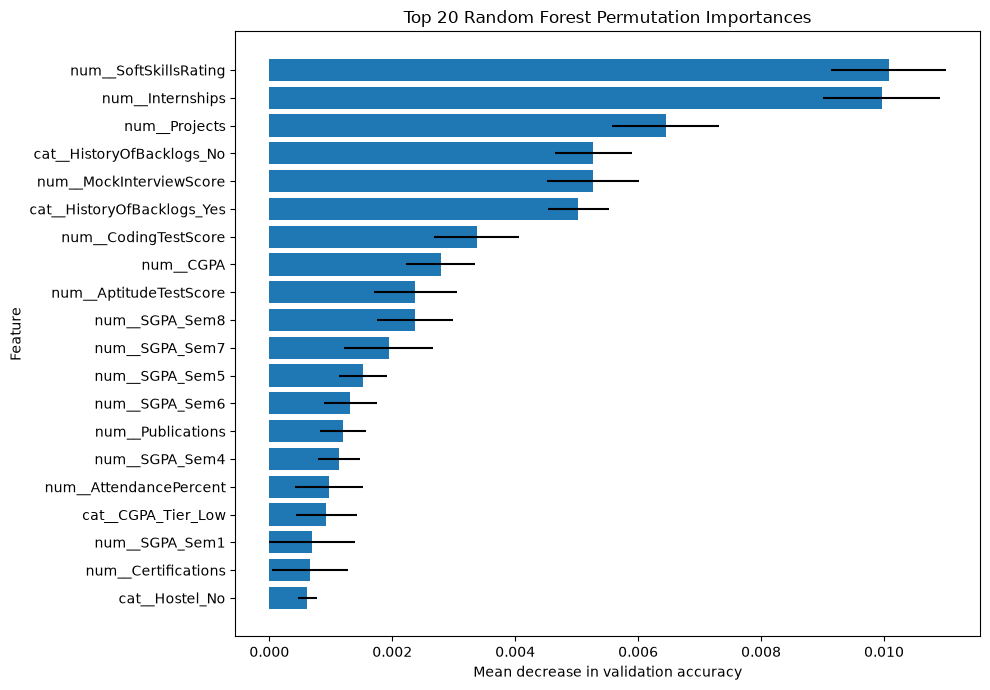

In [24]:
# ============================================================
# 24. PLOT TOP PERMUTATION IMPORTANCES
# ============================================================

top_n = min(20, len(importance_df))
plot_df = importance_df.head(top_n).sort_values("Mean_Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Mean_Importance"],
    xerr=plot_df["Std_Importance"]
)

plt.xlabel("Mean decrease in validation accuracy")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Random Forest Permutation Importances")
plt.tight_layout()
plt.show()


# Part H — `rf_vs_single_tree()` Function

The function compares Random Forest validation accuracy, a fixed single Decision Tree validation accuracy, and Random Forest OOB accuracy as the number of trees changes.


In [25]:
# ============================================================
# 25. rf_vs_single_tree() FUNCTION
# ============================================================

def rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
):
    results = []

    # Fixed single Decision Tree baseline
    dt = DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    )

    dt.fit(X_train, y_train)

    dt_val_acc = accuracy_score(
        y_val,
        dt.predict(X_val)
    )

    for n in n_estimators_list:
        rf_model = RandomForestClassifier(
            n_estimators=n,
            criterion="entropy",
            max_features="sqrt",
            bootstrap=True,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_train, y_train)

        rf_val_acc = accuracy_score(
            y_val,
            rf_model.predict(X_val)
        )

        results.append({
            "n_estimators": n,
            "RF_val_acc": rf_val_acc,
            "DT_val_acc": dt_val_acc,
            "OOB_acc": rf_model.oob_score_
        })

    results_df = pd.DataFrame(results)

    plt.figure(figsize=(10, 6))

    plt.plot(
        results_df["n_estimators"],
        results_df["RF_val_acc"],
        marker="o",
        label="Random Forest Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["DT_val_acc"],
        marker="s",
        label="Single Decision Tree Validation Accuracy"
    )

    plt.plot(
        results_df["n_estimators"],
        results_df["OOB_acc"],
        marker="^",
        label="Random Forest OOB Accuracy"
    )

    plt.xlabel("Number of Trees (n_estimators)")
    plt.ylabel("Accuracy")
    plt.title("Random Forest vs Single Decision Tree")
    plt.legend()
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df


/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/Users/poojithamusunuri/Documents/Machine Learning/.MLvenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


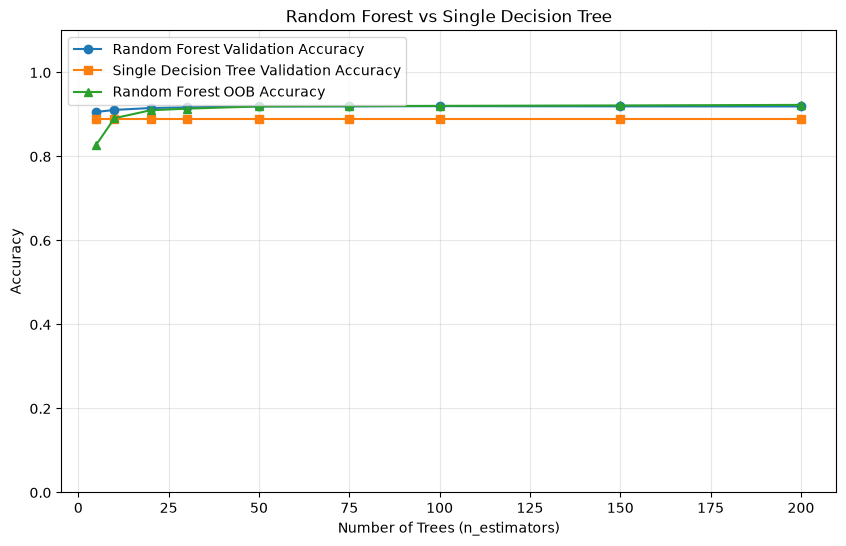

,n_estimators,RF_val_acc,DT_val_acc,OOB_acc
0,5,0.9061,0.8891,0.8284
1,10,0.9109,0.8891,0.8912
2,20,0.9154,0.8891,0.9101
3,30,0.9170,0.8891,0.9139
4,50,0.9193,0.8891,0.9193
5,75,0.9193,0.8891,0.9200
6,100,0.9199,0.8891,0.9206
7,150,0.9194,0.8891,0.9216
8,200,0.9192,0.8891,0.9229


In [26]:
# ============================================================
# 26. RUN THE FUNCTION
# ============================================================

n_estimators_list = [5, 10, 20, 30, 50, 75, 100, 150, 200]

rf_dt_results = rf_vs_single_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list
)

display(rf_dt_results.round(4))


In [27]:
# ============================================================
# 27. RANDOM FOREST RESULT WITH HIGHEST VALIDATION ACCURACY
# ============================================================

best_rf_row = rf_dt_results.loc[
    rf_dt_results["RF_val_acc"].idxmax()
]

print("Random Forest result with the highest validation accuracy:")
print("=" * 65)
print(best_rf_row.to_string())


Random Forest result with the highest validation accuracy:
n_estimators    100.000000
RF_val_acc        0.919867
DT_val_acc        0.889067
OOB_acc           0.920571


# Part I — Overall Model Comparison

In [28]:
# ============================================================
# 28. OVERALL COMPARISON
# ============================================================

overall_comparison = pd.DataFrame({
    "Model": [
        "Single Decision Tree",
        "Random Forest",
        "Manual Bootstrap Bagging",
        "BaggingClassifier"
    ],
    "Training Accuracy": [
        accuracy_score(y_train, dt_train_pred),
        accuracy_score(y_train, rf_train_pred),
        np.nan,
        accuracy_score(y_train, bagging_train_pred)
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, dt_val_pred),
        accuracy_score(y_val, rf_val_pred),
        manual_bagging_acc,
        accuracy_score(y_val, bagging_val_pred)
    ],
    "OOB Accuracy": [
        np.nan,
        rf.oob_score_,
        np.nan,
        np.nan
    ]
})

display(overall_comparison.round(4))


,Model,Training Accuracy,Validation Accuracy,OOB Accuracy
0,Single Decision Tree,1.0,0.8891,NaN
1,Random Forest,1.0,0.9199,0.9206
2,Manual Bootstrap Bagging,NaN,0.9206,NaN
3,BaggingClassifier,1.0,0.9207,NaN


# Final Learning Summary

After running the notebook, you should be able to explain:

1. How Random Forest combines many Decision Trees.
2. How bootstrap sampling creates different training sets.
3. What OOB observations are.
4. How OOB error changes as the number of trees increases.
5. What `max_features` means.
6. Why feature subsampling makes Random Forest trees different.
7. How manual bagging works.
8. How permutation importance is calculated.
9. How Random Forest and a single Decision Tree are evaluated on the same validation data.
10. Why model accuracy should be interpreted together with the dataset, preprocessing choices, and evaluation setup.
